## 
Comparison of the Confidence Intervals computed by the simulate function provided by evgam (simulate) and a traditional bootstrap method (GH).

Both methods are using a 1000 iterations.
##

In [61]:
import os

In [62]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
from copy import copy


In [63]:
from matplotlib import cm

In [64]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [65]:
import warnings
warnings.filterwarnings('ignore')


# READ FILES

In [ ]:
yearb=1941
yeare=2025

ifile='gh_simulate_bootstrap_B1000_1941_2025.nc'

dso = xr.open_dataset(ifile)
LocationDiff_q = dso['LocationDiff_q']
ScaleDiff_q = dso['ScaleDiff_q']
RLDiff_q = dso['RLDiff_q']
RiskRatios_q = dso['RiskRatios_q']
LocationDiff_qGH = dso['LocationDiff_qGH']
ScaleDiff_qGH = dso['ScaleDiff_qGH']
RLDiff_qGH = dso['RLDiff_qGH']
RiskRatios_qGH = dso['RiskRatios_qGH']


Tlon = dso.lon.data
Tlat = dso.lat.data

units = 'degree-days (°C)'


In [67]:
Tlabels = ['simulate, B=1000','GH, B=1000']
Tlocdiff = [LocationDiff_q,LocationDiff_qGH]
Tscadiff = [ScaleDiff_q,ScaleDiff_qGH]
TRL = [RLDiff_q,RLDiff_qGH]
TRR = [RiskRatios_q,RiskRatios_qGH]

In [68]:
v=[2,1,0]
proj=ccrs.PlateCarree()
Tquantile=[0.95,0.5,0.05]


In [69]:
import cmaps

Text(0.5, 0.98, 'Difference 2025-1941 Return Level 100 year')

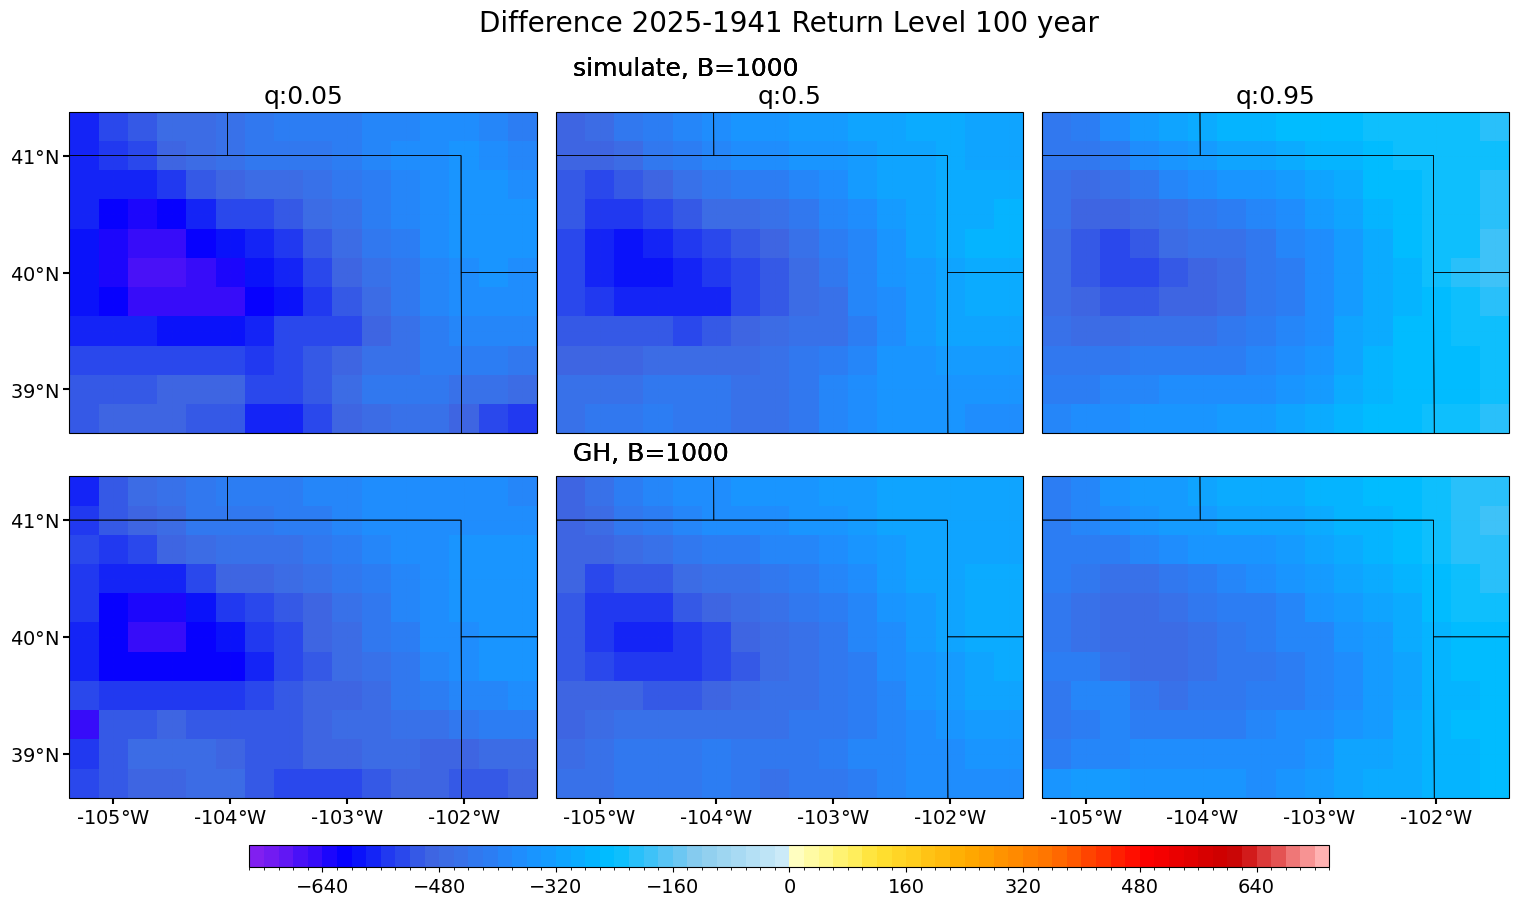

In [70]:
fig, ax = plt.subplots(nrows=2,ncols=len(Tquantile),figsize=(18,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  iq = v[ix]
  cc = TRL[0].isel(quantile=iq).plot.pcolormesh(ax=ax[ix],levels=np.arange(-740,760,20),cmap=cmaps.ncl_default,add_colorbar=False)
  cc = TRL[1].isel(quantile=iq).plot.pcolormesh(ax=ax[ix+3],levels=np.arange(-740,760,20),cmap=cmaps.ncl_default,add_colorbar=False)
  fig.text(0.38,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.57,f'{Tlabels[1]}',fontsize=18)
  ax[ix].set_title(f'q:{TRL[0]['quantile'][iq].data}',fontsize=18)   
  ax[ix+3].set_title(f'q:{TRL[1]['quantile'][iq].data}',fontsize=18)   
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title('',fontsize=18)  
  elif ix <=2:
    ax[ix].set_title(f'q:{Tquantile[v[ix]]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 
for ix in range(0,4,3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)

plt.suptitle(f'Difference {yeare}-{yearb} Return Level 100 year',fontsize=20)  

Text(0.5, 0.98, 'Difference 2025-1941 Location parameter')

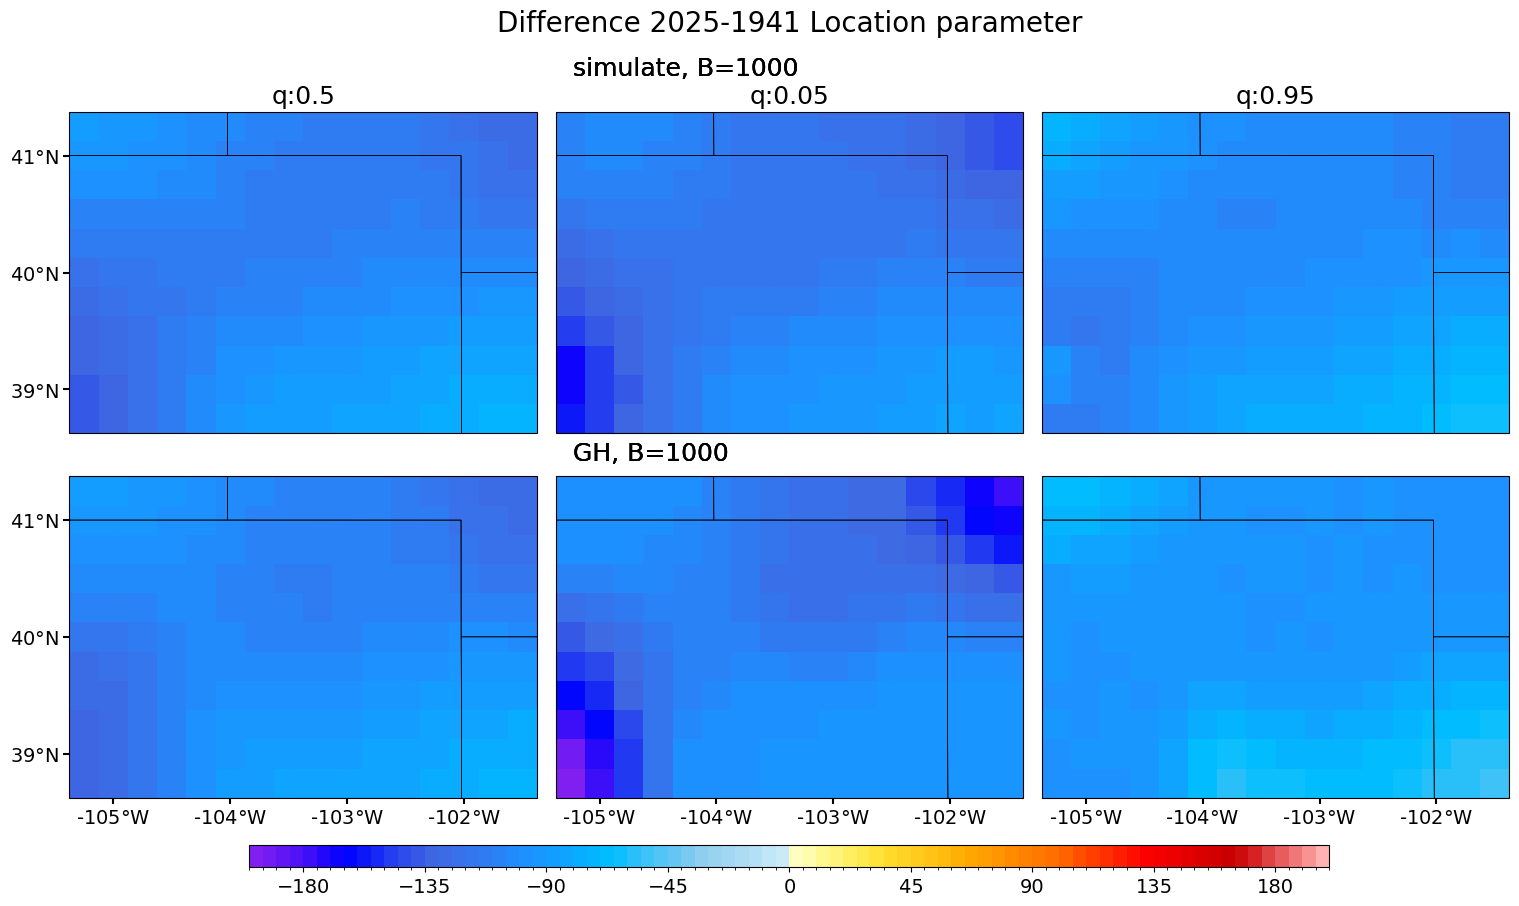

In [71]:
v=[1,2,0]

fig, ax = plt.subplots(nrows=2,ncols=len(Tquantile),figsize=(18,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  iq = v[ix]
  cc = Tlocdiff[0].isel(quantile=iq).plot.pcolormesh(ax=ax[ix],levels=np.arange(-200,205,5),cmap=cmaps.ncl_default,add_colorbar=False)
  cc = Tlocdiff[1].isel(quantile=iq).plot.pcolormesh(ax=ax[ix+3],levels=np.arange(-200,205,5),cmap=cmaps.ncl_default,add_colorbar=False)
  fig.text(0.38,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.57,f'{Tlabels[1]}',fontsize=18)
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title('',fontsize=18)  
  elif ix <=2:
    ax[ix].set_title(f'q:{Tquantile[v[ix]]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 
for ix in range(0,4,3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Difference {yeare}-{yearb} Location parameter',fontsize=20)  

Text(0.5, 0.98, 'Difference 2025-1941 Scale parameter')

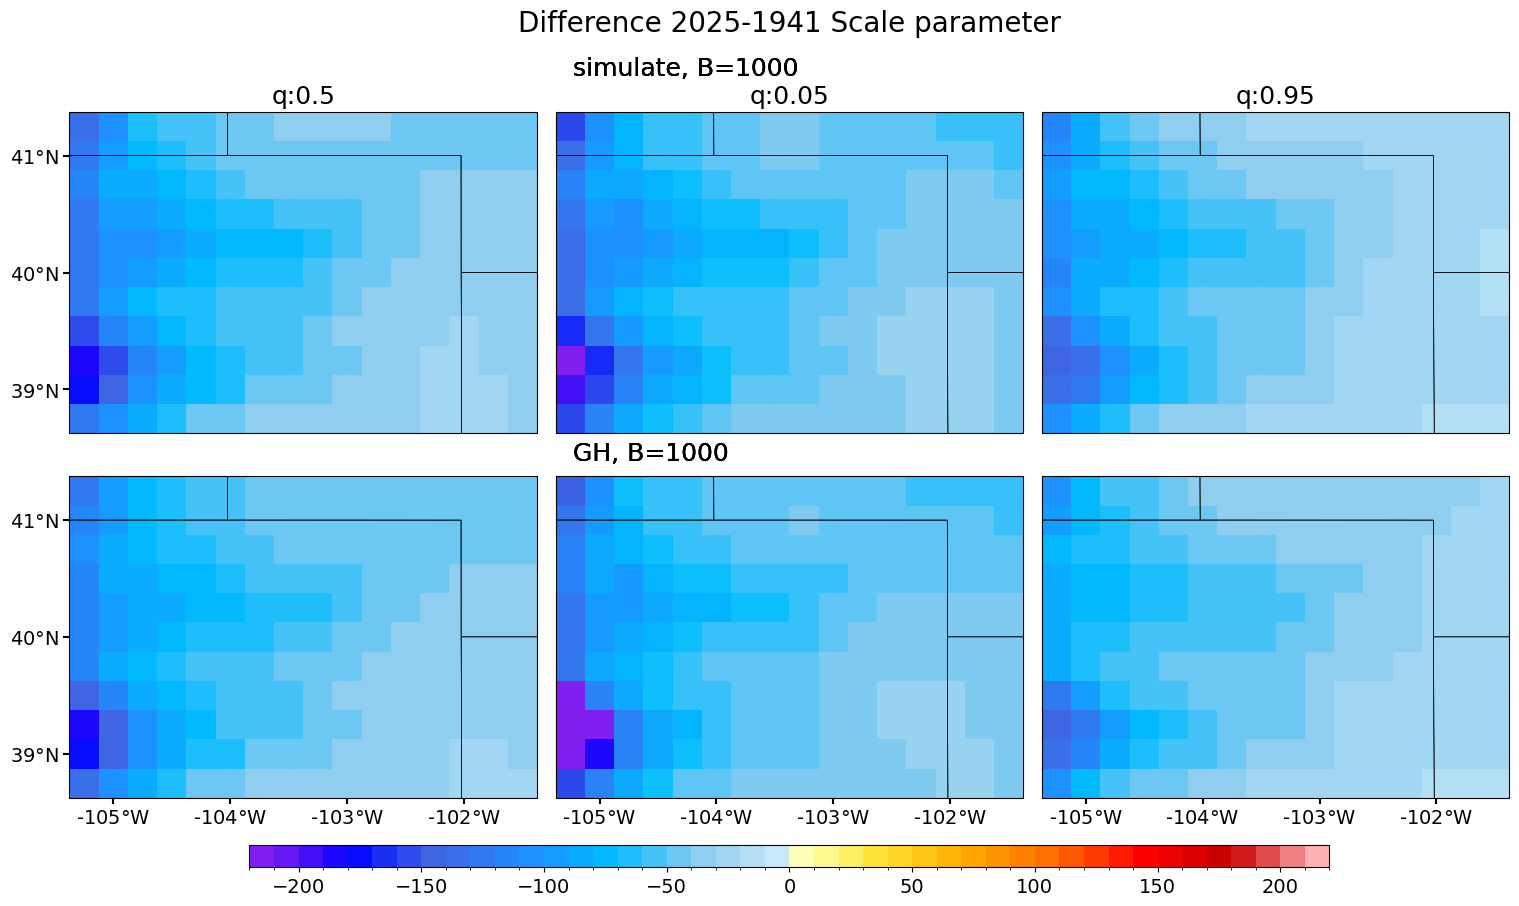

In [72]:
fig, ax = plt.subplots(nrows=2,ncols=len(Tquantile),figsize=(18,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  iq = v[ix]
  cc = Tscadiff[0].isel(quantile=iq).plot.pcolormesh(ax=ax[ix],levels=np.arange(-220,230,10),cmap=cmaps.ncl_default,add_colorbar=False)
  cc = Tscadiff[1].isel(quantile=iq).plot.pcolormesh(ax=ax[ix+3],levels=np.arange(-220,230,10),cmap=cmaps.ncl_default,add_colorbar=False)
  fig.text(0.38,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.57,f'{Tlabels[1]}',fontsize=18)
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title('',fontsize=18)  
  elif ix <=2:
    ax[ix].set_title(f'q:{Tquantile[v[ix]]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 
for ix in range(0,4,3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Difference {yeare}-{yearb} Scale parameter',fontsize=20)  

In [73]:
from matplotlib import cm
## Build colorbar
clevsa=np.arange(1.,70,1)
clevsb=np.arange(0,1.1,1)
rr_clevs=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('afmhot_r',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('Blues_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(3,cmap2.N-2)]

rr_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

##########
##########

Text(0.5, 0.98, 'Risk ratios')

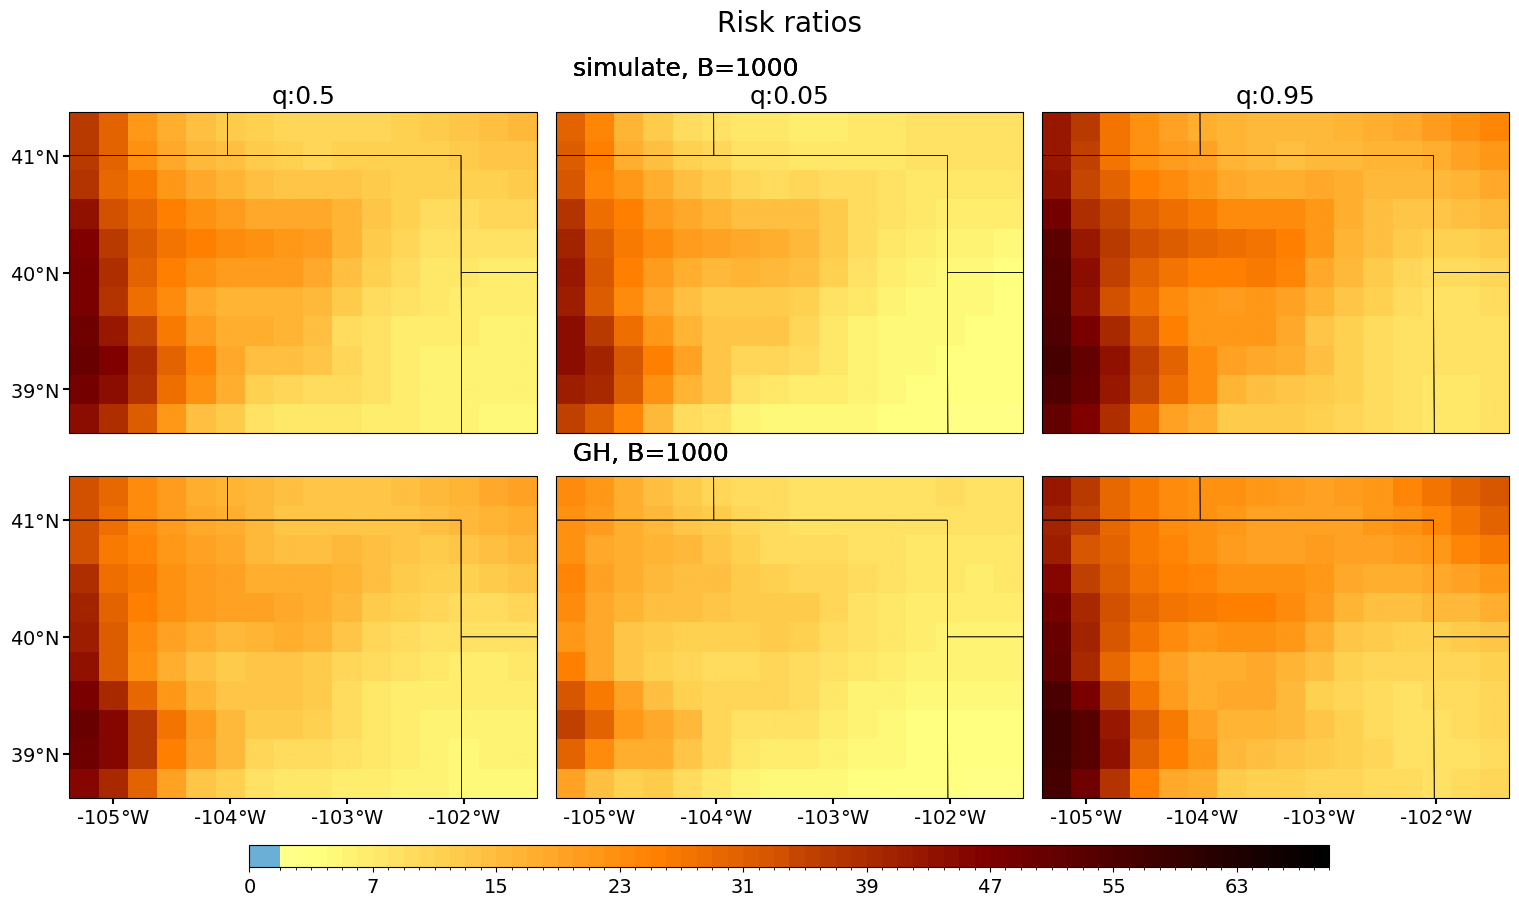

In [74]:
fig, ax = plt.subplots(nrows=2,ncols=len(Tquantile),figsize=(18,11),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  iq = v[ix]
  cc = TRR[0].isel(quantile=iq).plot.pcolormesh(ax=ax[ix],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
  cc = TRR[1].isel(quantile=iq).plot.pcolormesh(ax=ax[ix+3],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
  fig.text(0.38,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.38,0.57,f'{Tlabels[1]}',fontsize=18)
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title('',fontsize=18)  
  elif ix <=2:
    ax[ix].set_title(f'q:{Tquantile[v[ix]]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 
for ix in range(0,4,3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Risk ratios',fontsize=20)  

Text(0.5, 0.98, 'Difference 2025-1941 Return Level 100year : simulate - GH, B=1000 ')

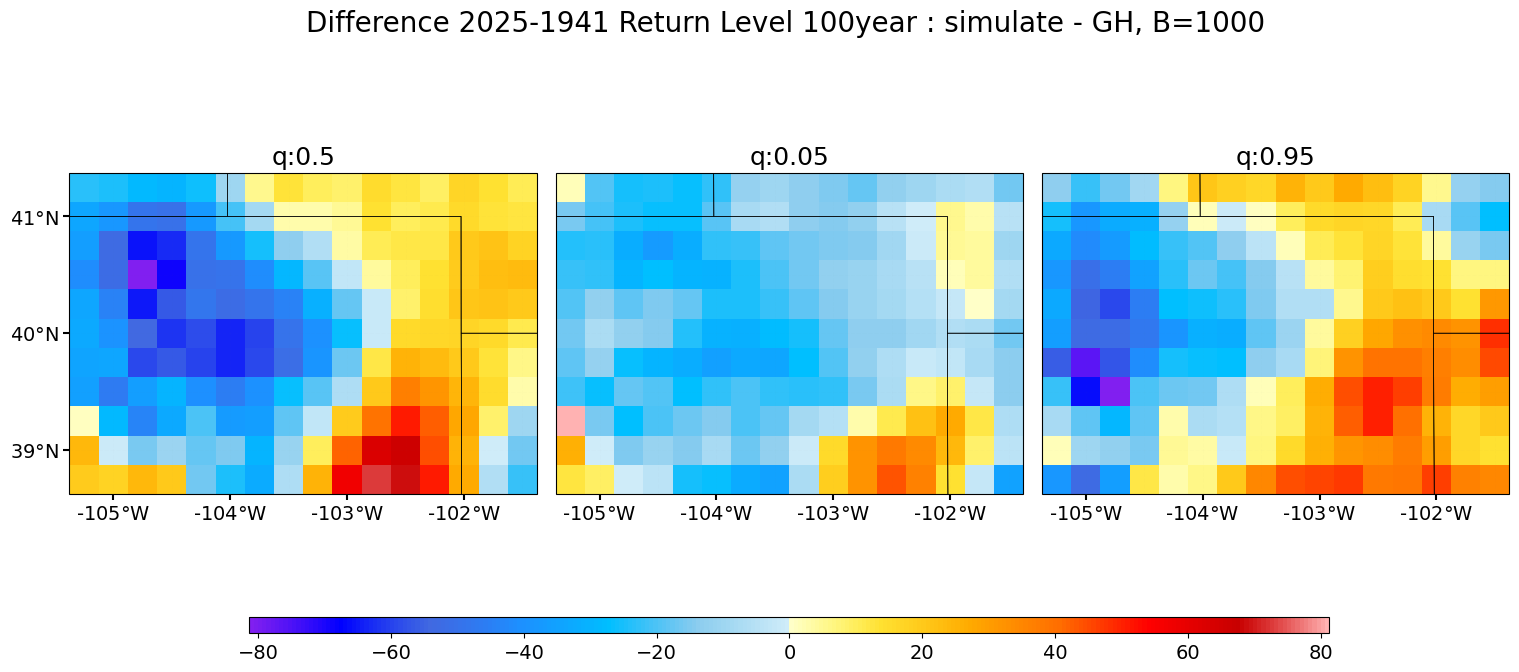

In [75]:
fig, ax = plt.subplots(nrows=1,ncols=len(Tquantile),figsize=(18,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  iq = v[ix]
  data = (TRL[0].isel(quantile=iq)-TRL[1].isel(quantile=iq))
  cc = data.plot.pcolormesh(ax=ax[ix],cmap=cmaps.ncl_default,add_colorbar=False)
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title(f'q:{Tquantile[v[ix]]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 
for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Difference {yeare}-{yearb} Return Level 100year : simulate - GH, B=1000 ',fontsize=20)  

Text(0.5, 0.98, 'Risk ratios 2025-1941 : simulate - GH, B=1000 ')

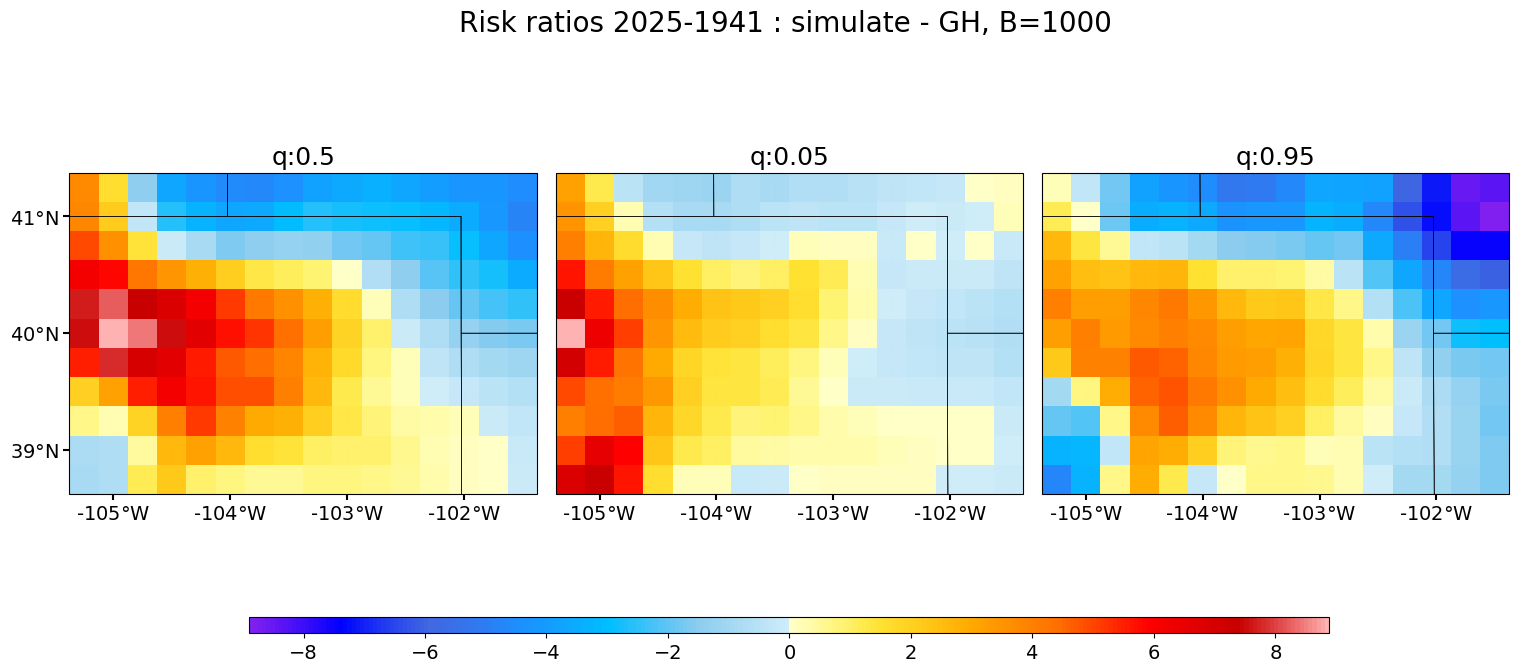

In [76]:
fig, ax = plt.subplots(nrows=1,ncols=len(Tquantile),figsize=(18,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  iq = v[ix]
  data = (TRR[0].isel(quantile=iq)-TRR[1].isel(quantile=iq))
  cc = data.plot.pcolormesh(ax=ax[ix],cmap=cmaps.ncl_default,add_colorbar=False)
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
    ax[ix].set_title(f'q:{Tquantile[v[ix]]}',fontsize=18)    
  else:
    ax[ix].set_title('',fontsize=18) 
for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Risk ratios {yeare}-{yearb} : simulate - GH, B=1000 ',fontsize=20)  